<p align="left">
  <a href="https://colab.research.google.com/github/wgomezf/analisis_datos/blob/main/02_Clasificación_lineal/ldamul.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" width="200">
  </a>
</p>

In [ ]:
#########################################################
# Autor: Wilfrido Gómez Flores (Cinvestav)              #
# E-mail: wgomez@cinvestav.mx                           #
# Curso: Análisis de datos                              #
# Tópico: LDA reductor de dimensionalidad multiclase    #
#########################################################

Carga bibliotecas necesarias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from scipy import linalg

Carga el conjunto de datos Iris con 3 clases, 150 muestras y 4 variables

In [ ]:
iris = load_iris()
df = pd.DataFrame(data=iris.data)
X = df.to_numpy() # Características
df = pd.DataFrame(data=iris.target)
Y = df.to_numpy() # Etiquetas de clase: 1,2 3
d = X.shape[1] # Número de variables
c = np.unique(Y).size # Número de clases

Calcula las matrices de dispersión inter- e intra-clase

In [ ]:
Sw = np.zeros((d, d))
Sb = np.zeros((d, d))
mu_g = np.mean(X, axis=0)
for i in range(c): # Para cada clase
    Xi = X[Y.flatten() == i, :]
    # Medias de la i-ésima clase
    mu_i = np.mean(Xi, axis=0)
    # Centralización al origen
    Xi_centered = Xi - mu_i
    # Matriz intra clase
    Sw = Sw + Xi_centered.T @ Xi_centered
    # Matriz interclase
    n_i = np.sum(Y == i)
    mu_diff = (mu_i - mu_g).reshape(-1, 1)
    Sb = Sb + n_i * (mu_diff @ mu_diff.T)

Resuelve el problema generalizado de valores propios y mapea el conjunto de datos de $\mathbb{R}^{4} \rightarrow \mathbb{R}^{2}$.

In [ ]:
# Resuelve el problema generalizado de valores propios
D_vals, W = linalg.eig(Sb, Sw)
# Ordena autovectores de mayor a menos
idx = np.argsort(D_vals.real)[::-1]
W = W[:, idx]
# Selecciona los vectores principales
Wlda = W[:, 0:c-1]
# Mapea el conjunto de datos
Z = (Wlda.T @ X.T).T

Grafica el conjunto de datos mapeado

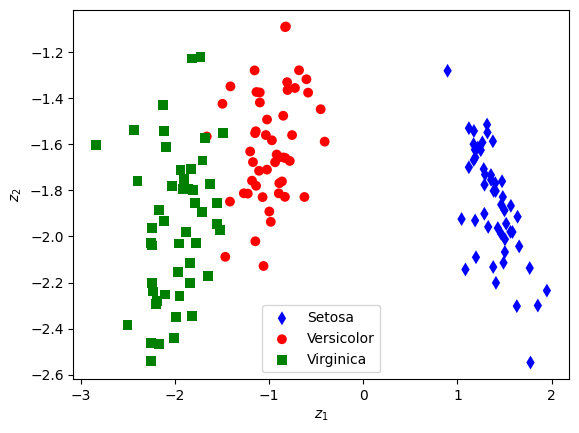

In [ ]:
plt.figure()
colors = ['red', 'green', 'blue']
markers = ['o', 's', 'd'] # circles, squares, diamonds
labels = ['Setosa', 'Versicolor', 'Virginica']
for i in range(c):
    mask = (Y.flatten() == i)
    plt.scatter(Z[mask, 0].real, Z[mask, 1].real,
                c=colors[i-1],
                marker=markers[i-1],
                s=50,
                label=labels[i-1],
                edgecolors='none')
plt.gca().set_box_aspect(None) # box on
plt.legend(labels, fontsize=10)
plt.xlabel('$z_1$', fontsize=10)
plt.ylabel('$z_2$', fontsize=10)
plt.grid(False)
plt.show()